In [1]:
# ============================================================================
# STREAMLINED EDA FOR ORAL CANCER DATASET (Memory-Optimized)
# ============================================================================
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns
from pathlib import Path
from PIL import Image
from collections import Counter, defaultdict
import gc  # Garbage collection for memory management
import warnings
warnings.filterwarnings('ignore')

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

In [2]:
# ============================================================================
# MOUNT GOOGLE DRIVE
# ============================================================================

def mount_google_drive():
    """Mount Google Drive"""
    print("=" * 70)
    print("MOUNTING GOOGLE DRIVE")
    print("=" * 70)

    from google.colab import drive
    drive.mount('/content/drive')

    print("\n✅ Google Drive mounted successfully!")
    print(f"📁 Drive location: /content/drive/MyDrive/")
    print("-" * 70)

In [3]:
# ============================================================================
# CONFIGURATION
# ============================================================================
mount_google_drive()

BASE_PATH = Path('/content/drive/MyDrive/LangGraph_Projects/Oral_Cancer/Histopathological_Oral_Cancer')

PATHS = {
    'normal_100x': BASE_PATH / 'First Set' / '100x_Normal',
    'oscc_100x': BASE_PATH / 'First Set' / '100x_OSCC',
    'normal_400x': BASE_PATH / 'Second Set' / '400x_Normal',
    'oscc_400x': BASE_PATH / 'Second Set' / '400x_OSCC'
}

print("=" * 80)
print("🔬 ORAL CANCER DATASET - STREAMLINED EDA")
print("=" * 80)
print(f"\n📁 Base Path: {BASE_PATH}\n")


MOUNTING GOOGLE DRIVE
Mounted at /content/drive

✅ Google Drive mounted successfully!
📁 Drive location: /content/drive/MyDrive/
----------------------------------------------------------------------
🔬 ORAL CANCER DATASET - STREAMLINED EDA

📁 Base Path: /content/drive/MyDrive/LangGraph_Projects/Oral_Cancer/Histopathological_Oral_Cancer



SECTION 1: DATASET STATISTICS

🔍 Checking normal_100x...
  ✅ 89 readable, ❌ 0 corrupted

🔍 Checking oscc_100x...
  ✅ 439 readable, ❌ 0 corrupted

🔍 Checking normal_400x...
  ✅ 201 readable, ❌ 0 corrupted

🔍 Checking oscc_400x...
  ✅ 495 readable, ❌ 0 corrupted

📊 DATASET SUMMARY
  Magnification   Class  Image Count  Readable  Corrupted
0          100x  Normal           89        89          0
1          100x    OSCC          439       439          0
2          400x  Normal          201       201          0
3          400x    OSCC          495       495          0

📈 CLASS DISTRIBUTION

100x Magnification:
  Normal: 89 (16.9%)
  OSCC:   439 (83.1%)
  Imbalance Ratio: 4.93:1

400x Magnification:
  Normal: 201 (28.9%)
  OSCC:   495 (71.1%)
  Imbalance Ratio: 2.46:1


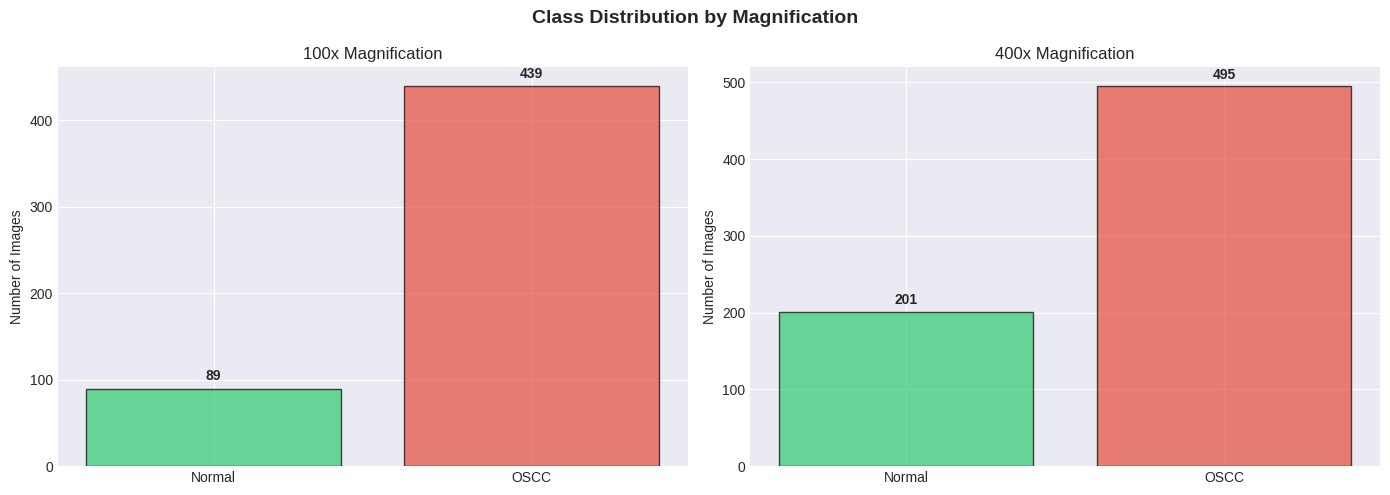

24

In [4]:
# ============================================================================
# SECTION 1: DATASET STATISTICS
# ============================================================================

print("=" * 80)
print("SECTION 1: DATASET STATISTICS")
print("=" * 80)

def collect_dataset_statistics():
    """Collect comprehensive statistics about the dataset"""

    stats = {
        'Category': [],
        'Magnification': [],
        'Class': [],
        'Image Count': [],
        'Readable': [],
        'Corrupted': []
    }

    total_images = 0
    total_corrupted = 0

    for category, path in PATHS.items():
        class_name = 'Normal' if 'normal' in category.lower() else 'OSCC'
        magnification = '100x' if '100x' in category else '400x'

        images = list(path.glob('*.jpg')) + list(path.glob('*.jpeg')) + list(path.glob('*.JPG'))
        count = len(images)
        total_images += count

        readable = 0
        corrupted = 0

        print(f"\n🔍 Checking {category}...")
        for img_path in images:
            try:
                img = Image.open(img_path)
                img.verify()
                readable += 1
            except Exception as e:
                corrupted += 1
                total_corrupted += 1
                print(f"  ⚠️  Corrupted: {img_path.name}")

        stats['Category'].append(category)
        stats['Magnification'].append(magnification)
        stats['Class'].append(class_name)
        stats['Image Count'].append(count)
        stats['Readable'].append(readable)
        stats['Corrupted'].append(corrupted)

        print(f"  ✅ {readable} readable, ❌ {corrupted} corrupted")

    return pd.DataFrame(stats), total_images, total_corrupted

df_stats, total_images, total_corrupted = collect_dataset_statistics()

print("\n" + "=" * 80)
print("📊 DATASET SUMMARY")
print("=" * 80)
print(df_stats[['Magnification', 'Class', 'Image Count', 'Readable', 'Corrupted']])

# Class distribution analysis
print("\n" + "=" * 80)
print("📈 CLASS DISTRIBUTION")
print("=" * 80)

for mag in ['100x', '400x']:
    mag_data = df_stats[df_stats['Magnification'] == mag]
    normal_count = mag_data[mag_data['Class'] == 'Normal']['Image Count'].values[0]
    oscc_count = mag_data[mag_data['Class'] == 'OSCC']['Image Count'].values[0]
    total = normal_count + oscc_count

    imbalance_ratio = oscc_count / normal_count

    print(f"\n{mag} Magnification:")
    print(f"  Normal: {normal_count} ({normal_count/total*100:.1f}%)")
    print(f"  OSCC:   {oscc_count} ({oscc_count/total*100:.1f}%)")
    print(f"  Imbalance Ratio: {imbalance_ratio:.2f}:1")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Class Distribution by Magnification', fontsize=14, fontweight='bold')

for idx, mag in enumerate(['100x', '400x']):
    mag_data = df_stats[df_stats['Magnification'] == mag]
    classes = mag_data['Class'].values
    counts = mag_data['Image Count'].values

    axes[idx].bar(classes, counts, color=['#2ecc71', '#e74c3c'], alpha=0.7, edgecolor='black')
    axes[idx].set_title(f'{mag} Magnification', fontsize=12)
    axes[idx].set_ylabel('Number of Images')

    for i, cnt in enumerate(counts):
        axes[idx].text(i, cnt + 10, str(cnt), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()
plt.close()
gc.collect()



SECTION 2: IMAGE DIMENSIONS

📊 DIMENSION STATISTICS:

Unique Resolutions: 2
Most common: (np.int64(2048), np.int64(1536))

100x:
  Width:  1536-2048 (mean: 1940)
  Height: 1536-2048 (mean: 1644)
  File Size: 2.56 MB (±0.39)

400x:
  Width:  1536-2048 (mean: 1961)
  Height: 1536-2048 (mean: 1623)
  File Size: 2.45 MB (±0.31)


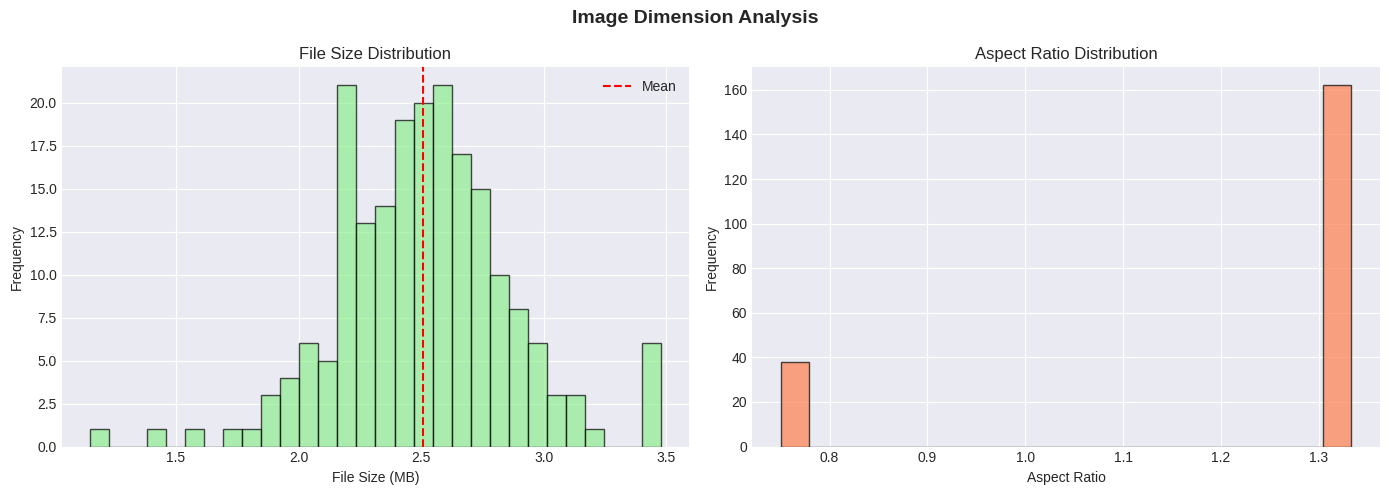

4645

In [5]:
# ============================================================================
# SECTION 2: IMAGE DIMENSIONS (Sample-based)
# ============================================================================

print("\n" + "=" * 80)
print("SECTION 2: IMAGE DIMENSIONS")
print("=" * 80)

def analyze_image_dimensions(sample_size=50):
    """Analyze dimensions with sampling to reduce memory"""

    dimension_data = {
        'Category': [],
        'Magnification': [],
        'Class': [],
        'Width': [],
        'Height': [],
        'Aspect_Ratio': [],
        'File_Size_MB': []
    }

    for category, path in PATHS.items():
        class_name = 'Normal' if 'normal' in category.lower() else 'OSCC'
        magnification = '100x' if '100x' in category else '400x'

        images = list(path.glob('*.jpg')) + list(path.glob('*.jpeg'))
        sample_images = np.random.choice(images, min(sample_size, len(images)), replace=False)

        for img_path in sample_images:
            try:
                img = Image.open(img_path)
                width, height = img.size
                img.close()  # Close immediately

                dimension_data['Category'].append(category)
                dimension_data['Magnification'].append(magnification)
                dimension_data['Class'].append(class_name)
                dimension_data['Width'].append(width)
                dimension_data['Height'].append(height)
                dimension_data['Aspect_Ratio'].append(width / height)
                dimension_data['File_Size_MB'].append(img_path.stat().st_size / (1024 * 1024))

            except Exception as e:
                continue

    return pd.DataFrame(dimension_data)

df_dimensions = analyze_image_dimensions(sample_size=50)

print("\n📊 DIMENSION STATISTICS:")
print(f"\nUnique Resolutions: {df_dimensions['Width'].astype(str).str.cat(df_dimensions['Height'].astype(str), sep='x').nunique()}")
print(f"Most common: {df_dimensions.groupby(['Width', 'Height']).size().idxmax()}")

for mag in ['100x', '400x']:
    mag_data = df_dimensions[df_dimensions['Magnification'] == mag]
    print(f"\n{mag}:")
    print(f"  Width:  {mag_data['Width'].min()}-{mag_data['Width'].max()} (mean: {mag_data['Width'].mean():.0f})")
    print(f"  Height: {mag_data['Height'].min()}-{mag_data['Height'].max()} (mean: {mag_data['Height'].mean():.0f})")
    print(f"  File Size: {mag_data['File_Size_MB'].mean():.2f} MB (±{mag_data['File_Size_MB'].std():.2f})")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Image Dimension Analysis', fontsize=14, fontweight='bold')

# File size distribution
axes[0].hist(df_dimensions['File_Size_MB'], bins=30, color='lightgreen', edgecolor='black', alpha=0.7)
axes[0].set_title('File Size Distribution')
axes[0].set_xlabel('File Size (MB)')
axes[0].set_ylabel('Frequency')
axes[0].axvline(df_dimensions['File_Size_MB'].mean(), color='red', linestyle='--', label='Mean')
axes[0].legend()

# Aspect ratio
axes[1].hist(df_dimensions['Aspect_Ratio'], bins=20, color='coral', edgecolor='black', alpha=0.7)
axes[1].set_title('Aspect Ratio Distribution')
axes[1].set_xlabel('Aspect Ratio')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()
plt.close()
gc.collect()


SECTION 3: IMAGE QUALITY ASSESSMENT

📊 QUALITY STATISTICS:

Brightness: 152.7 (±28.1)
Contrast:   41.6 (±10.1)

RGB Channels:
  Red:   141.2
  Green: 133.1
  Blue:  184.0


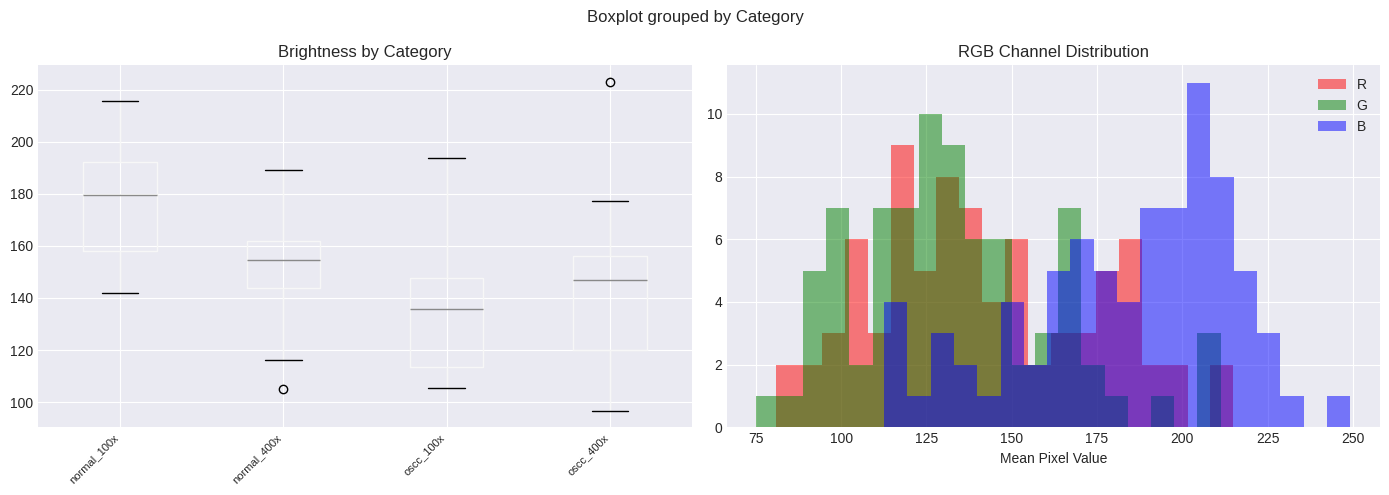

8981

In [6]:
# ============================================================================
# SECTION 3: IMAGE QUALITY (Reduced Sample)
# ============================================================================

print("\n" + "=" * 80)
print("SECTION 3: IMAGE QUALITY ASSESSMENT")
print("=" * 80)

def analyze_image_quality(sample_size=20):
    """Memory-efficient quality analysis"""

    quality_data = {
        'Category': [],
        'Mean_Brightness': [],
        'Contrast': [],
        'Mean_R': [],
        'Mean_G': [],
        'Mean_B': []
    }

    for category, path in PATHS.items():
        images = list(path.glob('*.jpg'))
        sample_images = np.random.choice(images, min(sample_size, len(images)), replace=False)

        for img_path in sample_images:
            try:
                # Load with reduced size for memory efficiency
                img = Image.open(img_path)
                img.thumbnail((512, 512))  # Reduce size for analysis
                img_array = np.array(img)

                if len(img_array.shape) == 3:
                    mean_brightness = np.mean(img_array)
                    gray = np.mean(img_array, axis=2)
                    contrast = np.std(gray)

                    quality_data['Category'].append(category)
                    quality_data['Mean_Brightness'].append(mean_brightness)
                    quality_data['Contrast'].append(contrast)
                    quality_data['Mean_R'].append(np.mean(img_array[:, :, 0]))
                    quality_data['Mean_G'].append(np.mean(img_array[:, :, 1]))
                    quality_data['Mean_B'].append(np.mean(img_array[:, :, 2]))

                img.close()
                del img_array

            except Exception as e:
                continue

    return pd.DataFrame(quality_data)

df_quality = analyze_image_quality(sample_size=20)

print("\n📊 QUALITY STATISTICS:")
print(f"\nBrightness: {df_quality['Mean_Brightness'].mean():.1f} (±{df_quality['Mean_Brightness'].std():.1f})")
print(f"Contrast:   {df_quality['Contrast'].mean():.1f} (±{df_quality['Contrast'].std():.1f})")
print(f"\nRGB Channels:")
print(f"  Red:   {df_quality['Mean_R'].mean():.1f}")
print(f"  Green: {df_quality['Mean_G'].mean():.1f}")
print(f"  Blue:  {df_quality['Mean_B'].mean():.1f}")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Image Quality Analysis', fontsize=14, fontweight='bold')

# Brightness by category
df_quality.boxplot(column='Mean_Brightness', by='Category', ax=axes[0])
axes[0].set_title('Brightness by Category')
axes[0].set_xlabel('')
plt.sca(axes[0])
plt.xticks(rotation=45, ha='right', fontsize=8)

# RGB channels
channels = ['Mean_R', 'Mean_G', 'Mean_B']
colors = ['red', 'green', 'blue']
for ch, color in zip(channels, colors):
    axes[1].hist(df_quality[ch], bins=20, alpha=0.5, label=ch.split('_')[1], color=color)
axes[1].set_title('RGB Channel Distribution')
axes[1].set_xlabel('Mean Pixel Value')
axes[1].legend()

plt.tight_layout()
plt.show()
plt.close()
gc.collect()

In [7]:
# ============================================================================
# SECTION 4: VISUAL SAMPLES
# ============================================================================

print("\n" + "=" * 80)
print("SECTION 4: SAMPLE IMAGES")
print("=" * 80)

def display_sample_grid(n_samples=3):
    """Display sample images (reduced to save memory)"""

    fig, axes = plt.subplots(4, n_samples, figsize=(15, 16))
    fig.suptitle('Sample Images from Each Category', fontsize=14, fontweight='bold')

    categories = ['normal_100x', 'oscc_100x', 'normal_400x', 'oscc_400x']
    labels = ['Normal 100x', 'OSCC 100x', 'Normal 400x', 'OSCC 400x']

    for row_idx, (category, label) in enumerate(zip(categories, labels)):
        path = PATHS[category]
        images = list(path.glob('*.jpg'))
        sample_images = np.random.choice(images, min(n_samples, len(images)), replace=False)

        for col_idx, img_path in enumerate(sample_images):
            try:
                img = Image.open(img_path)
                img.thumbnail((400, 400))  # Reduce size
                axes[row_idx, col_idx].imshow(img)
                axes[row_idx, col_idx].axis('off')

                if col_idx == 0:
                    axes[row_idx, col_idx].set_title(f'{label}', fontsize=10, fontweight='bold')

                img.close()
            except Exception as e:
                axes[row_idx, col_idx].axis('off')

    plt.tight_layout()
    plt.show()
    plt.close()
    gc.collect()

display_sample_grid(n_samples=3)

Output hidden; open in https://colab.research.google.com to view.


SECTION 5: PIXEL INTENSITY ANALYSIS (OPTIMIZED)

🎨 Analyzing pixel intensities...

📊 PIXEL INTENSITY STATISTICS:

NORMAL_100X:
  Red:   181.9 (±18.9)
  Green: 176.2 (±22.8)
  Blue:  207.2 (±17.5)

OSCC_100X:
  Red:   136.3 (±28.8)
  Green: 124.8 (±23.1)
  Blue:  163.4 (±30.9)

NORMAL_400X:
  Red:   137.9 (±30.4)
  Green: 121.8 (±26.2)
  Blue:  184.9 (±26.4)

OSCC_400X:
  Red:   146.8 (±33.1)
  Green: 123.4 (±24.7)
  Blue:  192.7 (±23.1)


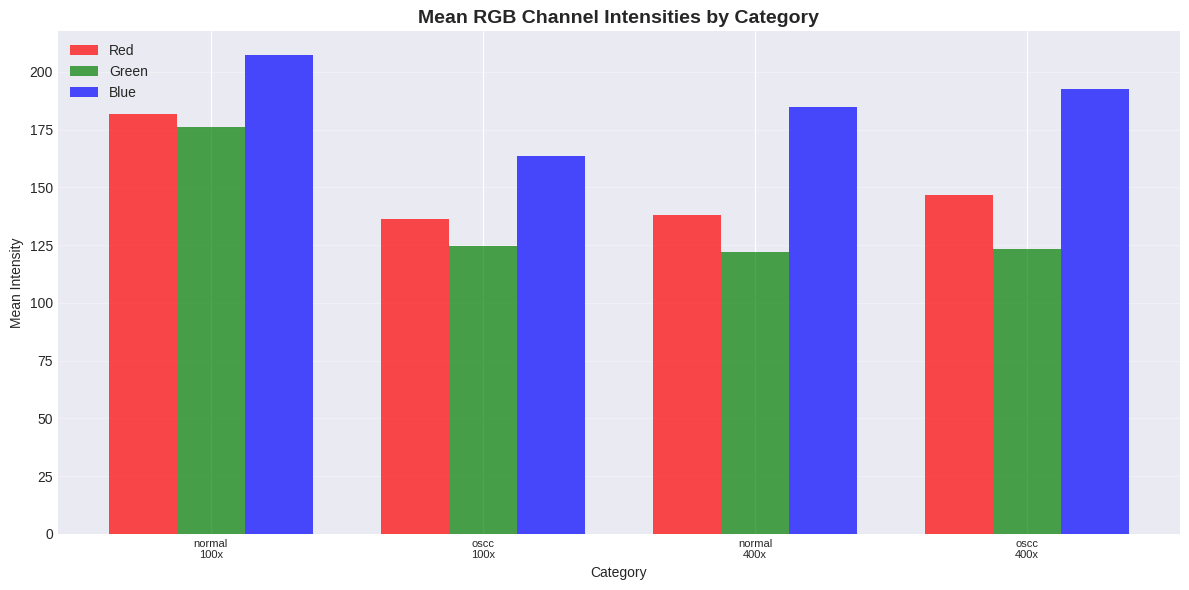

21

In [8]:
# ============================================================================
# SECTION 5: PIXEL INTENSITY (MEMORY-OPTIMIZED)
# ============================================================================

print("\n" + "=" * 80)
print("SECTION 5: PIXEL INTENSITY ANALYSIS (OPTIMIZED)")
print("=" * 80)

def analyze_pixel_intensities_efficient(sample_size=10):
    """Memory-efficient pixel intensity analysis"""

    intensity_stats = {
        'Category': [],
        'Mean_R': [],
        'Mean_G': [],
        'Mean_B': [],
        'Std_R': [],
        'Std_G': [],
        'Std_B': []
    }

    print("\n🎨 Analyzing pixel intensities...")

    for category, path in PATHS.items():
        images = list(path.glob('*.jpg'))
        sample_images = np.random.choice(images, min(sample_size, len(images)), replace=False)

        r_vals, g_vals, b_vals = [], [], []

        for img_path in sample_images:
            try:
                img = Image.open(img_path)
                img.thumbnail((256, 256))  # Drastically reduce for intensity calc
                img_array = np.array(img)

                if len(img_array.shape) == 3:
                    # Sample pixels instead of using all
                    sample_indices = np.random.choice(img_array.shape[0] * img_array.shape[1],
                                                     min(1000, img_array.shape[0] * img_array.shape[1]),
                                                     replace=False)
                    flat = img_array.reshape(-1, 3)
                    sampled = flat[sample_indices]

                    r_vals.append(sampled[:, 0].mean())
                    g_vals.append(sampled[:, 1].mean())
                    b_vals.append(sampled[:, 2].mean())

                img.close()
                del img_array

            except Exception as e:
                continue

        if r_vals:
            intensity_stats['Category'].append(category)
            intensity_stats['Mean_R'].append(np.mean(r_vals))
            intensity_stats['Mean_G'].append(np.mean(g_vals))
            intensity_stats['Mean_B'].append(np.mean(b_vals))
            intensity_stats['Std_R'].append(np.std(r_vals))
            intensity_stats['Std_G'].append(np.std(g_vals))
            intensity_stats['Std_B'].append(np.std(b_vals))

        gc.collect()

    return pd.DataFrame(intensity_stats)

df_intensity = analyze_pixel_intensities_efficient(sample_size=10)

print("\n📊 PIXEL INTENSITY STATISTICS:")
for _, row in df_intensity.iterrows():
    print(f"\n{row['Category'].upper()}:")
    print(f"  Red:   {row['Mean_R']:.1f} (±{row['Std_R']:.1f})")
    print(f"  Green: {row['Mean_G']:.1f} (±{row['Std_G']:.1f})")
    print(f"  Blue:  {row['Mean_B']:.1f} (±{row['Std_B']:.1f})")

# Visualization
fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(df_intensity))
width = 0.25

ax.bar(x - width, df_intensity['Mean_R'], width, label='Red', color='red', alpha=0.7)
ax.bar(x, df_intensity['Mean_G'], width, label='Green', color='green', alpha=0.7)
ax.bar(x + width, df_intensity['Mean_B'], width, label='Blue', color='blue', alpha=0.7)

ax.set_title('Mean RGB Channel Intensities by Category', fontsize=14, fontweight='bold')
ax.set_xlabel('Category')
ax.set_ylabel('Mean Intensity')
ax.set_xticks(x)
ax.set_xticklabels([cat.replace('_', '\n') for cat in df_intensity['Category']], fontsize=8)
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()
plt.close()
gc.collect()

In [9]:
# ============================================================================
# FINAL SUMMARY
# ============================================================================

print("\n" + "=" * 80)
print("📋 FINAL SUMMARY & RECOMMENDATIONS")
print("=" * 80)

print(f"\n✅ DATASET OVERVIEW:")
print(f"  Total Images: {total_images}")
print(f"  Corrupted: {total_corrupted}")
print(f"  Data Integrity: {((total_images-total_corrupted)/total_images*100):.1f}%")

print(f"\n✅ KEY FINDINGS:")
for mag in ['100x', '400x']:
    mag_data = df_stats[df_stats['Magnification'] == mag]
    normal = mag_data[mag_data['Class']=='Normal']['Image Count'].values[0]
    oscc = mag_data[mag_data['Class']=='OSCC']['Image Count'].values[0]
    print(f"  {mag}: Normal={normal}, OSCC={oscc} (Ratio: {oscc/normal:.2f}:1)")

print(f"\n✅ PREPROCESSING RECOMMENDATIONS:")
print("  1. Resize to 224×224")
print("  2. Apply stratified split due to class imbalance")
print("  3. Use class weights or data augmentation")
print("  4. Normalize using ImageNet stats for transfer learning")
print("  5. Train separate models for 100x and 400x magnifications")
print("  6. Rotation, flipping, brightness adjustment, cropping and resizing")

print("\n" + "=" * 80)
print("🎉 STREAMLINED EDA COMPLETE!")
print("=" * 80)


📋 FINAL SUMMARY & RECOMMENDATIONS

✅ DATASET OVERVIEW:
  Total Images: 1224
  Corrupted: 0
  Data Integrity: 100.0%

✅ KEY FINDINGS:
  100x: Normal=89, OSCC=439 (Ratio: 4.93:1)
  400x: Normal=201, OSCC=495 (Ratio: 2.46:1)

✅ PREPROCESSING RECOMMENDATIONS:
  1. Resize to 224×224
  2. Apply stratified split due to class imbalance
  3. Use class weights or data augmentation
  4. Normalize using ImageNet stats for transfer learning
  5. Train separate models for 100x and 400x magnifications
  6. Rotation, flipping, brightness adjustment, cropping and resizing

🎉 STREAMLINED EDA COMPLETE!
